In [1]:
!pip install -q xgboost scikit-learn boto3 pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.7/65.7 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 7.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [11]:
!pip -q install "sagemaker<3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.6/444.6 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.2/82.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 3.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sagemaker-train 1.15.0 requires sag

In [1]:
from google.colab import userdata
import os
os.environ["AWS_ACCESS_KEY_ID"]     = userdata.get("AWS_ACCESS_KEY_ID")
os.environ["AWS_SECRET_ACCESS_KEY"] = userdata.get("AWS_SECRET_ACCESS_KEY")
os.environ["AWS_DEFAULT_REGION"]    = userdata.get("AWS_DEFAULT_REGION")

In [2]:
import boto3
import sagemaker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings

warnings.filterwarnings("ignore")

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /root/.config/sagemaker/config.yaml


In [6]:
session = sagemaker.Session()
role = "arn:aws:iam::883244340451:role/SageMakerExecutionRole"
BUCKET = session.default_bucket()
PREFIX = "fraud-detection"
region = session.boto_region_name

print(f"Role : {role}")
print(f"Bucket : {BUCKET}")
print(f"Region : {region}")
print(f"SageMaker: {sagemaker.__version__}")


Role : arn:aws:iam::883244340451:role/SageMakerExecutionRole
Bucket : sagemaker-ap-south-1-883244340451
Region : ap-south-1
SageMaker: 2.257.3


In [7]:
df = pd.read_csv("creditcard.csv")
print("Shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 3 rows:")
df.head(3)

Shape: (284807, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

First 3 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [8]:
pd.DataFrame({"Missing_Value":df.isna().sum(),"Data_Type":df.dtypes})

,Missing_Value,Data_Type
Time,0,float64
V1,0,float64
V2,0,float64
V3,0,float64
V4,0,float64
V5,0,float64
V6,0,float64
V7,0,float64
V8,0,float64
V9,0,float64


In [9]:
print("=== Basic Statistics ===")
df.describe().round(2)

=== Basic Statistics ===


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,...,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00
mean,94813.86,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,...,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,88.35,0.00
std,47488.15,1.96,1.65,1.52,1.42,1.38,1.33,1.24,1.19,1.10,...,0.73,0.73,0.62,0.61,0.52,0.48,0.40,0.33,250.12,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,...,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,54201.50,-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,...,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,84692.00,0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,...,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,139320.50,1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,...,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.16,0.00
max,172792.00,2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,...,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,25691.16,1.00


In [11]:
class_counts = df["Class"].value_counts()
fraud_pct = df["Class"].mean() * 100

print("=== Class Distribution ===")
print(f"Legitimate (0): {class_counts[0]:,}  ({100 - fraud_pct:.2f}%)")
print(f"Fraud (1)     : {class_counts[1]:,}  ({fraud_pct:.4f}%)")
print(f"Imbalance ratio: {class_counts[0]/class_counts[1]:.0f}:1")


=== Class Distribution ===
Legitimate (0): 284,315  (99.83%)
Fraud (1)     : 492  (0.1727%)
Imbalance ratio: 578:1


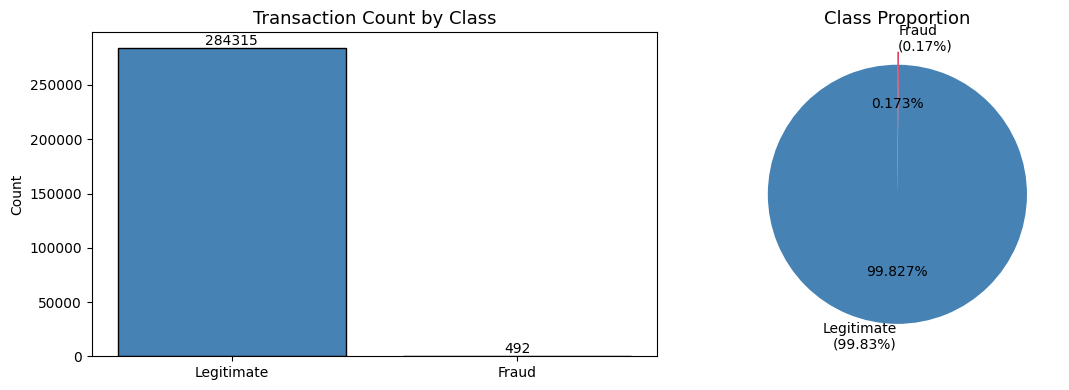

In [12]:
fig,axes = plt.subplots(1,2,figsize =(12,4))
#count plot
axes[0].bar(["Legitimate", "Fraud"], class_counts.values,color=["steelblue", "crimson"], edgecolor="black")
axes[0].set_title("Transaction Count by Class", fontsize=13)
axes[0].set_ylabel("Count")
for container in axes[0].containers:
    axes[0].bar_label(container)

# Percentage pie chart
axes[1].pie([class_counts[0], class_counts[1]],
            labels=["Legitimate\n(99.83%)", "Fraud\n(0.17%)"],
            colors=["steelblue", "crimson"],
            autopct="%1.3f%%", startangle=90,
            explode=(0, 0.1))   # Explode the fraud slice for emphasis
axes[1].set_title("Class Proportion", fontsize=13)

plt.tight_layout()
plt.show()

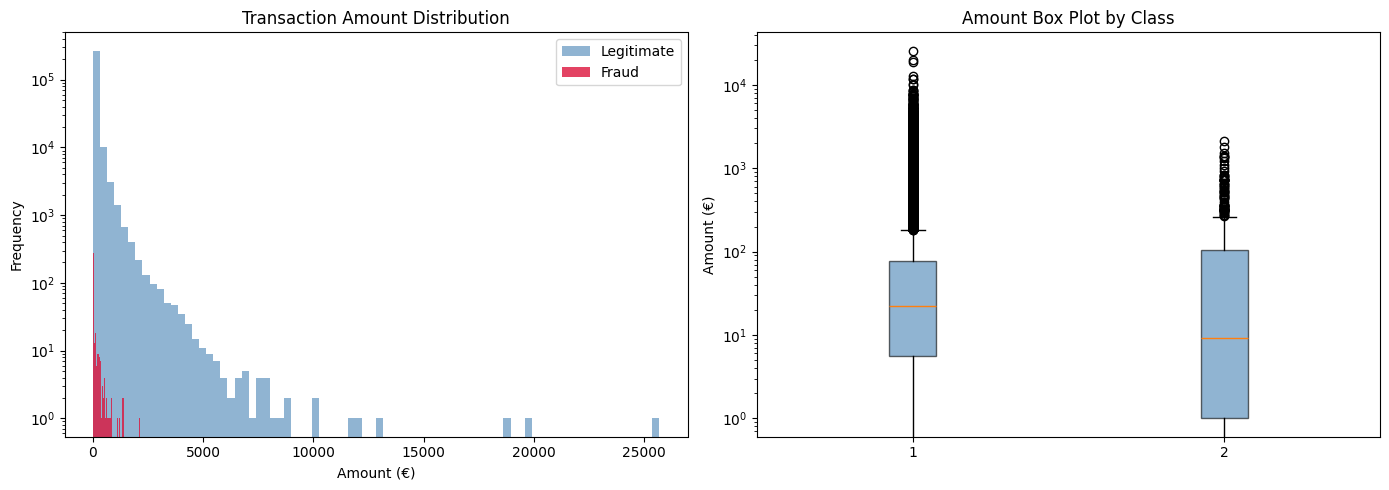

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

legit  = df[df["Class"] == 0]["Amount"]
fraud  = df[df["Class"] == 1]["Amount"]

# Distribution (log scale because amounts span huge range)
axes[0].hist(legit,  bins=80, alpha=0.6, color="steelblue", label="Legitimate")
axes[0].hist(fraud,  bins=80, alpha=0.8, color="crimson",   label="Fraud")
axes[0].set_xlabel("Amount (€)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Transaction Amount Distribution")
axes[0].set_yscale("log")   # Log scale so fraud is visible
axes[0].legend()

# Box plot
df["Class_Label"] = df["Class"].map({0: "Legitimate", 1: "Fraud"})
axes[1].boxplot([legit, fraud], label=["Legitimate", "Fraud"],
                patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1].set_ylabel("Amount (€)")
axes[1].set_title("Amount Box Plot by Class")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

In [14]:
print(f"Legitimate — Mean: €{legit.mean():.2f}, Median: €{legit.median():.2f}, Max: €{legit.max():.2f}")
print(f"Fraud — Mean: €{fraud.mean():.2f}, Median: €{fraud.median():.2f}, Max: €{fraud.max():.2f}")

Legitimate — Mean: €88.29, Median: €22.00, Max: €25691.16
Fraud — Mean: €122.21, Median: €9.25, Max: €2125.87


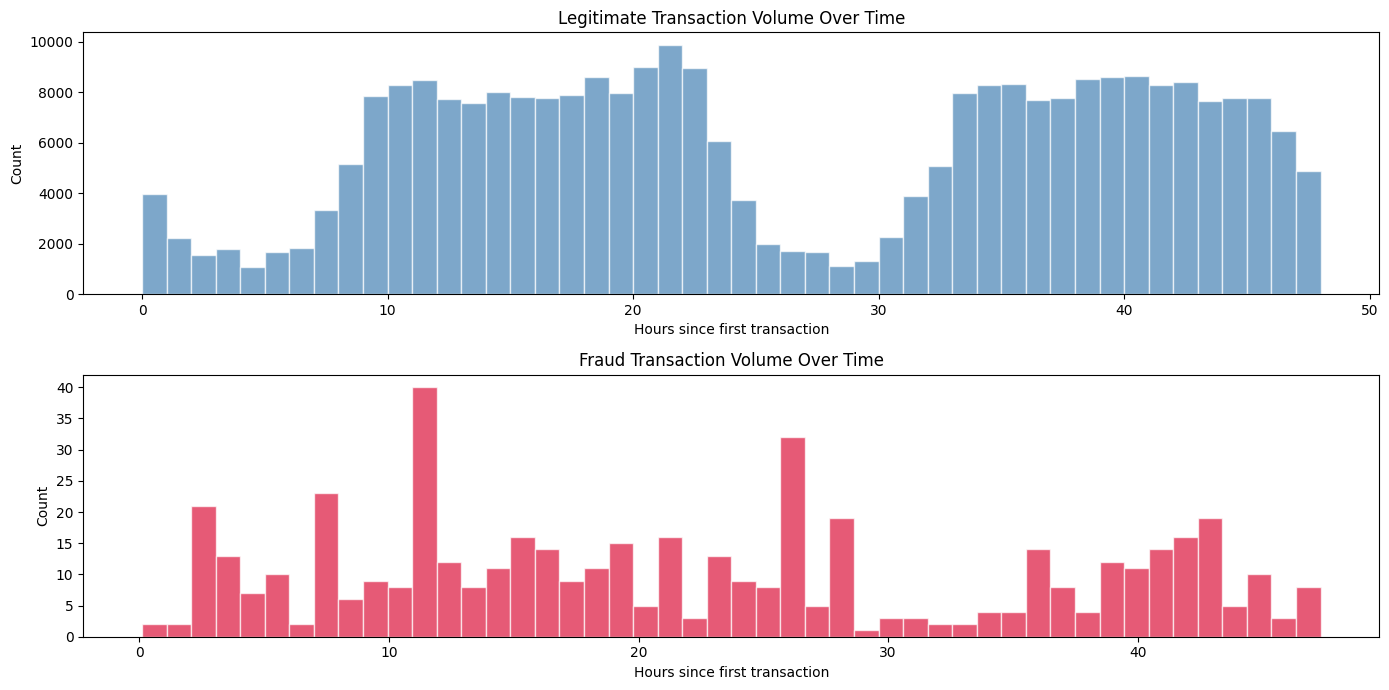

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

legit_time = df[df["Class"] == 0]["Time"] / 3600   # Convert seconds → hours
fraud_time = df[df["Class"] == 1]["Time"] / 3600

axes[0].hist(legit_time, bins=48, color="steelblue", alpha=0.7, edgecolor="white")
axes[0].set_title("Legitimate Transaction Volume Over Time")
axes[0].set_xlabel("Hours since first transaction")
axes[0].set_ylabel("Count")

axes[1].hist(fraud_time, bins=48, color="crimson", alpha=0.7, edgecolor="white")
axes[1].set_title("Fraud Transaction Volume Over Time")
axes[1].set_xlabel("Hours since first transaction")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [16]:
correlations = df.drop("Class_Label", axis=1).corr()["Class"].drop("Class")
correlations_sorted = correlations.abs().sort_values(ascending=False)

print("Top 10 features most correlated with fraud:")
print(correlations_sorted.head(10))

Top 10 features most correlated with fraud:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485
Name: Class, dtype: float64


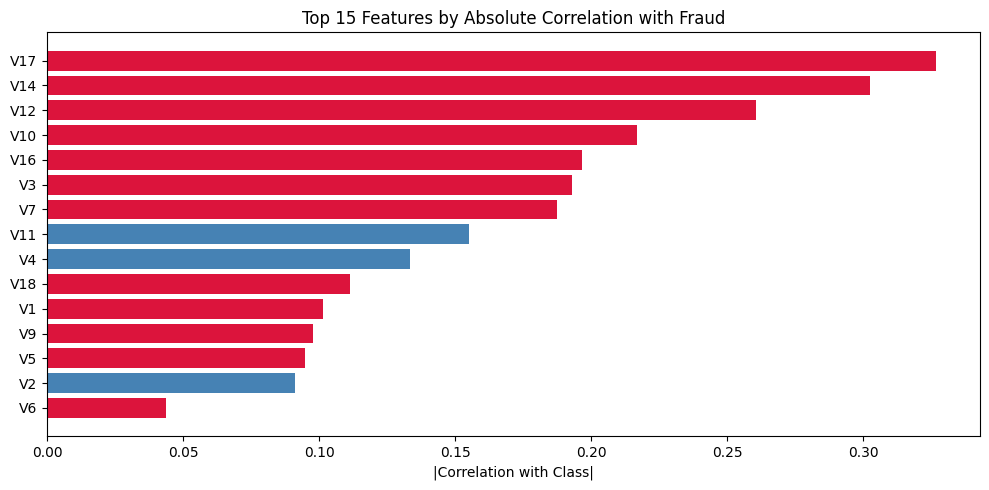

In [17]:
# Plot
fig, ax = plt.subplots(figsize=(10, 5))
top_feats = correlations_sorted.head(15)
colors = ["crimson" if correlations[f] < 0 else "steelblue" for f in top_feats.index]
ax.barh(top_feats.index[::-1], top_feats.values[::-1], color=colors[::-1])
ax.set_xlabel("|Correlation with Class|")
ax.set_title("Top 15 Features by Absolute Correlation with Fraud")
plt.tight_layout()
plt.show()

In [18]:
print("=" * 55)
print("EDA SUMMARY")
print("=" * 55)
print(f"  Total transactions : {len(df):,}")
print(f"  Fraud transactions : {df['Class'].sum():,}")
print(f"  Imbalance ratio : {int(class_counts[0]/class_counts[1])}:1")
print(f"  Missing values : {df.isnull().sum().sum()}")
print(f"  Features : V1-V28 (PCA), Time, Amount")
print()
print("Key findings:")
print("  1. Extreme imbalance → use scale_pos_weight = 575 in XGBoost")
print("  2. Amount and Time need scaling (V1-V28 are already scaled by PCA)")
print("  3. Metric to optimise: AUC-PR (precision-recall), NOT accuracy")
print("  4. V17, V14, V12, V10 are most correlated with fraud")

EDA SUMMARY
  Total transactions : 284,807
  Fraud transactions : 492
  Imbalance ratio : 577:1
  Missing values : 0
  Features : V1-V28 (PCA), Time, Amount

Key findings:
  1. Extreme imbalance → use scale_pos_weight = 575 in XGBoost
  2. Amount and Time need scaling (V1-V28 are already scaled by PCA)
  3. Metric to optimise: AUC-PR (precision-recall), NOT accuracy
  4. V17, V14, V12, V10 are most correlated with fraud


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df_clean = df.drop(columns=["Class_Label"], errors="ignore").copy()

print(f"Clean shape: {df_clean.shape}")
print(f"Columns: {df_clean.columns.tolist()}")

Clean shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [20]:
X = df_clean.drop("Class", axis=1)    # All columns except target
y = df_clean["Class"]                  # Target column only

# Stratified split preserves the 0.17% fraud ratio in both train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # Reproducible split
    stratify=y            # Critical: preserve class ratio
)

print(f"Train size : {X_train.shape[0]:,}")
print(f"Test size  : {X_test.shape[0]:,}")
print(f"Train fraud: {y_train.sum():,} ({y_train.mean()*100:.3f}%)")
print(f"Test fraud : {y_test.sum():,}  ({y_test.mean()*100:.3f}%)")

Train size : 227,845
Test size  : 56,962
Train fraud: 394 (0.173%)
Test fraud : 98  (0.172%)


In [21]:
scaler = StandardScaler()

# Fit on TRAIN only — never on test (prevents data leakage)
X_train[["Amount", "Time"]] = scaler.fit_transform(X_train[["Amount", "Time"]])

# Transform test using the SAME scaler fitted on train
X_test[["Amount", "Time"]]  = scaler.transform(X_test[["Amount", "Time"]])

print("Scaled Amount stats (train):")
print(f"  Mean: {X_train['Amount'].mean():.4f}  (should be ~0)")
print(f"  Std : {X_train['Amount'].std():.4f}   (should be ~1)")

Scaled Amount stats (train):
  Mean: -0.0000  (should be ~0)
  Std : 1.0000   (should be ~1)


In [22]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Legitimate in train : {neg:,}")
print(f"Fraud in train : {pos:,}")
print(f"scale_pos_weight : {scale_pos_weight:.1f}")

Legitimate in train : 227,451
Fraud in train : 394
scale_pos_weight : 577.3


In [23]:
# SageMaker's built-in XGBoost expects:
#   - Target column in the FIRST position
#   - No column headers (headerless CSV)
#   - Numeric values only

train_data = pd.concat([y_train.reset_index(drop=True), X_train.reset_index(drop=True)], axis=1)
test_data  = pd.concat([y_test.reset_index(drop=True), X_test.reset_index(drop=True)],  axis=1)

In [24]:
import os
os.makedirs("datasets",exist_ok=True)
train_data.to_csv("datasets/train.csv", index=False, header=False)
test_data.to_csv( "datasets/test.csv",  index=False, header=False)

In [26]:
s3 = boto3.client("s3")
s3.upload_file("datasets/train.csv", BUCKET, f"{PREFIX}/data/train.csv")
s3.upload_file("datasets/test.csv",  BUCKET, f"{PREFIX}/data/test.csv")
print("Uploaded to S3")

Uploaded to S3


In [27]:
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

model = xgb.XGBClassifier(
    objective          = "binary:logistic",
    scale_pos_weight   = int(scale_pos_weight),
    eval_metric        = "aucpr",
    n_estimators       = 500,
    max_depth          = 6,
    learning_rate      = 0.1,
    gamma              = 1,
    min_child_weight   = 5,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    early_stopping_rounds = 30,
    random_state       = 42,
    use_label_encoder  = False
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred      = model.predict(X_test)
y_pred_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_prob):.4f}")
print(f"PR-AUC   : {average_precision_score(y_test, y_pred_prob):.4f}")

[0]	validation_0-aucpr:0.27364
[35]	validation_0-aucpr:0.71489
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     56864
       Fraud       0.25      0.84      0.38        98

    accuracy                           1.00     56962
   macro avg       0.62      0.92      0.69     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC  : 0.9553
PR-AUC   : 0.7171


In [28]:
import tarfile

# Save in XGBoost native format (what SageMaker expects)
model.get_booster().save_model("xgboost-model")

# SageMaker requires model.tar.gz with the file named exactly "xgboost-model"
with tarfile.open("model.tar.gz", "w:gz") as tar:
    tar.add("xgboost-model")

s3.upload_file("model.tar.gz", BUCKET, f"{PREFIX}/model-output/model.tar.gz")

model_s3_uri = f"s3://{BUCKET}/{PREFIX}/model-output/model.tar.gz"
print(f"Model uploaded: {model_s3_uri}")

Model uploaded: s3://sagemaker-ap-south-1-883244340451/fraud-detection/model-output/model.tar.gz


In [31]:
from sagemaker.xgboost.model import XGBoostModel

xgb_model = XGBoostModel(
    model_data = model_s3_uri,
    role = role,
    framework_version = "1.7-1",
    sagemaker_session = session
)

print("Deploying endpoint... (takes ~5 minutes)")

predictor = xgb_model.deploy(
    initial_instance_count = 1,
    instance_type = "ml.m5.large",
    endpoint_name = "fraud-detector-prod"
)

print(f"Endpoint deployed: fraud-detector-prod")

Deploying endpoint... (takes ~5 minutes)
------!Endpoint deployed: fraud-detector-prod


In [42]:
from sagemaker.serializers import CSVSerializer

predictor.serializer = CSVSerializer()

# Test with one fraud sample and one legit sample
fraud_sample  = X_test[y_test == 1].iloc[0].values.reshape(1, -1)
legit_sample  = X_test[y_test == 0].iloc[0].values.reshape(1, -1)

fraud_score = predictor.predict(fraud_sample)[0][0]
legit_score = predictor.predict(legit_sample)[0][0]

print(f"Fraud sample score : {fraud_score}  (should be high)")
print(f"Legit sample score : {legit_score}  (should be low)")

Fraud sample score : 0.9866225123405457  (should be high)
Legit sample score : 0.013619713485240936  (should be low)


In [43]:
import numpy as np
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve, f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions directly from local model (no endpoint needed for eval)
y_pred_prob = model.predict_proba(X_test)[:, 1]
y_test_arr  = y_test.values

print(f"Got {len(y_pred_prob):,} probability scores")
print(f"Sample predictions: {y_pred_prob[:5].round(4)}")

Got 56,962 probability scores
Sample predictions: [0.2716 0.2725 0.2624 0.2795 0.3863]


In [44]:
threshold = 0.5
y_pred = (y_pred_prob >= threshold).astype(int)

print("=" * 55)
print(f"EVALUATION RESULTS (threshold = {threshold})")
print("=" * 55)
print("\nClassification Report:")
print(classification_report(y_test_arr, y_pred,
                            target_names=["Legitimate", "Fraud"],
                            digits=4))

roc_auc = roc_auc_score(y_test_arr, y_pred_prob)
pr_auc  = average_precision_score(y_test_arr, y_pred_prob)

print(f"ROC-AUC Score : {roc_auc:.4f}")
print(f"PR-AUC Score  : {pr_auc:.4f}")

cm = confusion_matrix(y_test_arr, y_pred)
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix:")
print(f"  True Negatives  : {tn:,}")
print(f"  False Positives : {fp:,}  ← false alarms")
print(f"  False Negatives : {fn:,}  ← missed frauds (COSTLY)")
print(f"  True Positives  : {tp:,}  ← caught frauds")

EVALUATION RESULTS (threshold = 0.5)

Classification Report:
              precision    recall  f1-score   support

  Legitimate     0.9997    0.9956    0.9977     56864
       Fraud     0.2470    0.8367    0.3814        98

    accuracy                         0.9953     56962
   macro avg     0.6234    0.9162    0.6895     56962
weighted avg     0.9984    0.9953    0.9966     56962

ROC-AUC Score : 0.9553
PR-AUC Score  : 0.7171

Confusion Matrix:
  True Negatives  : 56,614
  False Positives : 250  ← false alarms
  False Negatives : 16  ← missed frauds (COSTLY)
  True Positives  : 82  ← caught frauds


In [45]:
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = []

for t in thresholds:
    preds = (y_pred_prob >= t).astype(int)
    f1 = f1_score(y_test_arr, preds, zero_division=0)
    f1_scores.append(f1)

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

print(f"Best threshold : {best_threshold:.2f}")
print(f"Best F1 Score  : {best_f1:.4f}")

y_pred_best = (y_pred_prob >= best_threshold).astype(int)
print("\nClassification Report at optimal threshold:")
print(classification_report(y_test_arr, y_pred_best,
                            target_names=["Legitimate", "Fraud"],
                            digits=4))

Best threshold : 0.73
Best F1 Score  : 0.8000

Classification Report at optimal threshold:
              precision    recall  f1-score   support

  Legitimate     0.9996    0.9998    0.9997     56864
       Fraud     0.8506    0.7551    0.8000        98

    accuracy                         0.9994     56962
   macro avg     0.9251    0.8774    0.8998     56962
weighted avg     0.9993    0.9994    0.9993     56962



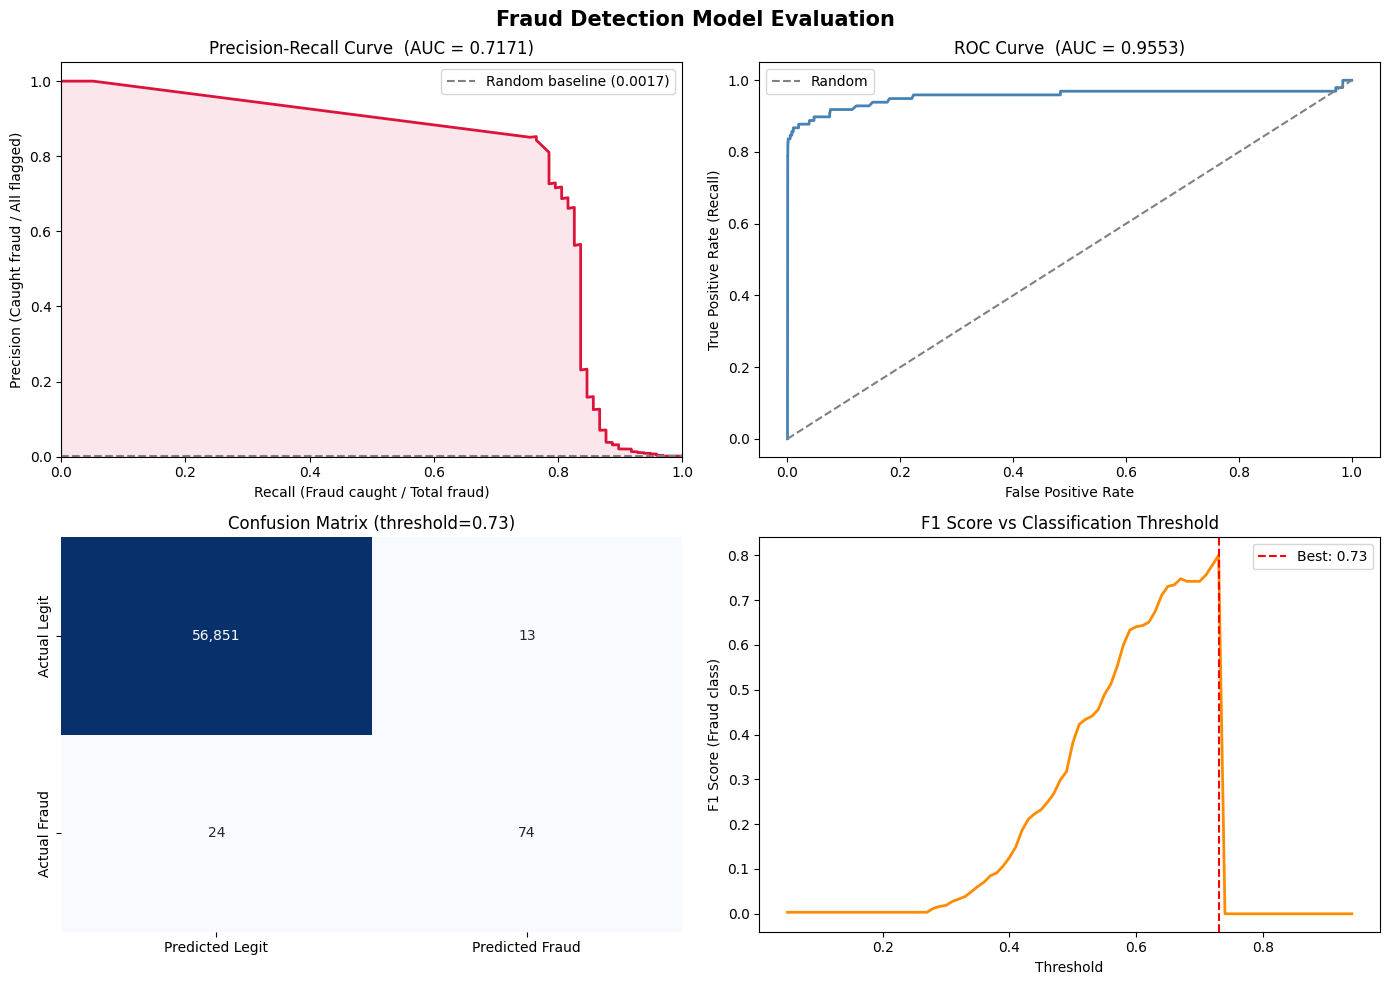

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Fraud Detection Model Evaluation", fontsize=15, fontweight="bold")

# Plot 1: Precision-Recall Curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test_arr, y_pred_prob)
axes[0, 0].plot(recall_vals, precision_vals, color="crimson", lw=2)
axes[0, 0].axhline(y=y_test_arr.mean(), color="gray", linestyle="--",
                   label=f"Random baseline ({y_test_arr.mean():.4f})")
axes[0, 0].fill_between(recall_vals, precision_vals, alpha=0.1, color="crimson")
axes[0, 0].set_xlabel("Recall (Fraud caught / Total fraud)")
axes[0, 0].set_ylabel("Precision (Caught fraud / All flagged)")
axes[0, 0].set_title(f"Precision-Recall Curve  (AUC = {pr_auc:.4f})")
axes[0, 0].legend()
axes[0, 0].set_xlim([0, 1])
axes[0, 0].set_ylim([0, 1.05])

# Plot 2: ROC Curve
fpr_vals, tpr_vals, _ = roc_curve(y_test_arr, y_pred_prob)
axes[0, 1].plot(fpr_vals, tpr_vals, color="steelblue", lw=2)
axes[0, 1].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate (Recall)")
axes[0, 1].set_title(f"ROC Curve  (AUC = {roc_auc:.4f})")
axes[0, 1].legend()

# Plot 3: Confusion Matrix Heatmap
cm_best = confusion_matrix(y_test_arr, y_pred_best)
sns.heatmap(cm_best, annot=True, fmt=",", cmap="Blues",
            xticklabels=["Predicted Legit", "Predicted Fraud"],
            yticklabels=["Actual Legit",    "Actual Fraud"],
            ax=axes[1, 0], cbar=False)
axes[1, 0].set_title(f"Confusion Matrix (threshold={best_threshold:.2f})")

# Plot 4: F1 vs Threshold
axes[1, 1].plot(thresholds, f1_scores, color="darkorange", lw=2)
axes[1, 1].axvline(x=best_threshold, color="red", linestyle="--",
                   label=f"Best: {best_threshold:.2f}")
axes[1, 1].set_xlabel("Threshold")
axes[1, 1].set_ylabel("F1 Score (Fraud class)")
axes[1, 1].set_title("F1 Score vs Classification Threshold")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [47]:
cm_best = confusion_matrix(y_test_arr, y_pred_best)
tn, fp, fn, tp = cm_best.ravel()

scale             = 5       # test set = 20% of data
avg_fraud_amount  = 122.21  # from your EDA
false_alarm_cost  = 2       # €2 per investigation

fraud_caught_euros   = tp * scale * avg_fraud_amount
fraud_missed_euros   = fn * scale * avg_fraud_amount
investigation_cost   = fp * scale * false_alarm_cost

print("=" * 55)
print("BUSINESS IMPACT ESTIMATE (full dataset projection)")
print("=" * 55)
print(f"  Fraud caught (TP)       : {tp * scale:,} transactions")
print(f"  Fraud missed (FN)       : {fn * scale:,} transactions  ← COST")
print(f"  False alarms (FP)       : {fp * scale:,} transactions  ← COST")
print()
print(f"  Avg fraud amount        : €{avg_fraud_amount:.2f}")
print(f"  Fraud prevented         : €{fraud_caught_euros:,.0f}")
print(f"  Fraud missed (loss)     : €{fraud_missed_euros:,.0f}")
print(f"  Investigation cost      : €{investigation_cost:,.0f}")
print(f"  Net benefit             : €{fraud_caught_euros - fraud_missed_euros - investigation_cost:,.0f}")
print()
print(f"  Recall (fraud caught %) : {tp/(tp+fn)*100:.1f}%")
print(f"  Precision               : {tp/(tp+fp)*100:.1f}%")

BUSINESS IMPACT ESTIMATE (full dataset projection)
  Fraud caught (TP)       : 370 transactions
  Fraud missed (FN)       : 120 transactions  ← COST
  False alarms (FP)       : 65 transactions  ← COST

  Avg fraud amount        : €122.21
  Fraud prevented         : €45,218
  Fraud missed (loss)     : €14,665
  Investigation cost      : €130
  Net benefit             : €30,422

  Recall (fraud caught %) : 75.5%
  Precision               : 85.1%


In [48]:
import json

OPTIMAL_THRESHOLD = float(round(best_threshold, 2))
print(f"Using threshold: {OPTIMAL_THRESHOLD}")

with open("optimal_threshold.json", "w") as f:
    json.dump({"threshold": OPTIMAL_THRESHOLD}, f)

s3.upload_file(
    "optimal_threshold.json",
    BUCKET,
    f"{PREFIX}/config/optimal_threshold.json"
)

ENDPOINT_NAME = "fraud-detector-prod"

print("Using existing production endpoint:", ENDPOINT_NAME)

Using threshold: 0.73
Using existing production endpoint: fraud-detector-prod


In [50]:
runtime = boto3.client("sagemaker-runtime", region_name=region)

FEATURE_ORDER = [
    "Time",
    "V1","V2","V3","V4","V5","V6","V7","V8","V9","V10",
    "V11","V12","V13","V14","V15","V16","V17","V18","V19","V20",
    "V21","V22","V23","V24","V25","V26","V27","V28",
    "Amount"
]

def predict_fraud_direct(features_list, threshold=OPTIMAL_THRESHOLD):
    payload  = ",".join(map(str, features_list))
    response = runtime.invoke_endpoint(
        EndpointName = ENDPOINT_NAME,
        ContentType  = "text/csv",
        Body         = payload
    )
    probability = float(response["Body"].read().decode("utf-8").strip())
    return {
        "fraud_probability": round(probability, 4),
        "is_fraud"         : probability >= threshold,
        "risk_level"       : "HIGH"   if probability >= 0.7
                        else "MEDIUM" if probability >= 0.3
                        else "LOW"
    }

# Get feature values in FEATURE_ORDER from X_test
fraud_idx = y_test[y_test == 1].index[0]
legit_idx = y_test[y_test == 0].index[0]

fraud_features = [X_test.loc[fraud_idx][f] for f in FEATURE_ORDER]
legit_features = [X_test.loc[legit_idx][f] for f in FEATURE_ORDER]

print("=== Test 1: Known FRAUD transaction ===")
print(predict_fraud_direct(fraud_features))

print("\n=== Test 2: Known LEGITIMATE transaction ===")
print(predict_fraud_direct(legit_features))

=== Test 1: Known FRAUD transaction ===
{'fraud_probability': 0.9866, 'is_fraud': True, 'risk_level': 'HIGH'}

=== Test 2: Known LEGITIMATE transaction ===
{'fraud_probability': 0.0136, 'is_fraud': False, 'risk_level': 'LOW'}


In [62]:
# This tests the complete path:
# Python → API Gateway → Lambda → SageMaker Endpoint → back


import requests

API_URL = "https://qpdin21s7f.execute-api.ap-south-1.amazonaws.com/prod/predict"

def build_api_payload(feature_row, feature_names):
    """Convert a numpy row to the JSON dict the API expects."""
    return {name: float(val) for name, val in zip(feature_names, feature_row)}

# Test Case 1: Fraud transaction
fraud_sample = X_test.loc[y_test[y_test == 1].index[0]].values
feature_names = X_train.columns.tolist()
payload_fraud = build_api_payload(fraud_sample, feature_names)

print("=" * 55)
print("TEST 1: Known FRAUD transaction")
print("=" * 55)
response = requests.post(API_URL, json=payload_fraud, timeout=30)
print(f"HTTP Status : {response.status_code}")
result = response.json()
for k, v in result.items():
    print(f"  {k:25s}: {v}")

print()

# Test Case 2: Legitimate transaction
legit_sample = X_test.loc[y_test[y_test == 0].index[0]].values
payload_legit = build_api_payload(legit_sample, feature_names)

print("=" * 55)
print("TEST 2: Known LEGITIMATE transaction")
print("=" * 55)
response = requests.post(API_URL, json=payload_legit, timeout=30)
print(f"HTTP Status : {response.status_code}")
result = response.json()
for k, v in result.items():
    print(f"  {k:25s}: {v}")

TEST 1: Known FRAUD transaction
HTTP Status : 200
  fraud_detected           : True
  fraud_probability        : 0.9866
  risk_level               : HIGH
  recommended_action       : BLOCK
  threshold_used           : 0.73
  model_endpoint           : fraud-detector-prod

TEST 2: Known LEGITIMATE transaction
HTTP Status : 200
  fraud_detected           : False
  fraud_probability        : 0.0136
  risk_level               : LOW
  recommended_action       : APPROVE
  threshold_used           : 0.73
  model_endpoint           : fraud-detector-prod


In [63]:
# Send 50 random test transactions and measure:
#   - Correct fraud detections (TP rate)
#   - Average latency per request

import time

# Sample: 25 fraud + 25 legitimate
fraud_indices = y_test[y_test == 1].index[:25]
legit_indices = y_test[y_test == 0].index[:25]
test_indices  = list(fraud_indices) + list(legit_indices)

results = []
latencies = []

print(f"Sending {len(test_indices)} requests to API...")

for idx in test_indices:
    features = X_test.loc[idx].values
    true_label = y_test.loc[idx]
    payload = build_api_payload(features, feature_names)

    start = time.time()
    resp = requests.post(API_URL, json=payload, timeout=30)
    latency_ms = (time.time() - start) * 1000

    result = resp.json()
    predicted = int(result["fraud_detected"])
    latencies.append(latency_ms)
    results.append({
        "true_label": true_label,
        "predicted" : predicted,
        "probability": result["fraud_probability"],
        "correct"   : true_label == predicted,
        "latency_ms": round(latency_ms, 1)
    })

results_df = pd.DataFrame(results)
correct = results_df["correct"].mean() * 100

print(f"\nBatch Test Results:")
print(f"  Correct predictions: {results_df['correct'].sum()}/50 ({correct:.0f}%)")
print(f"  Average latency    : {results_df['latency_ms'].mean():.0f} ms")
print(f"  P95 latency        : {results_df['latency_ms'].quantile(0.95):.0f} ms")
print(f"  Min latency        : {results_df['latency_ms'].min():.0f} ms")
print(f"  Max latency        : {results_df['latency_ms'].max():.0f} ms")

Sending 50 requests to API...

Batch Test Results:
  Correct predictions: 46/50 (92%)
  Average latency    : 702 ms
  P95 latency        : 725 ms
  Min latency        : 677 ms
  Max latency        : 872 ms


In [64]:
# Cell 32: Test error handling
# -----------------------------
# Verify that the API gracefully rejects bad requests.

print("TEST: Missing fields (should return 400)")
resp = requests.post(API_URL, json={"V1": -1.35, "Amount": 100}, timeout=10)
print(f"  Status: {resp.status_code}")
print(f"  Body  : {resp.json()}\n")

print("TEST: Invalid JSON (should return 400)")
resp = requests.post(API_URL,
                     data="this is not json",
                     headers={"Content-Type": "application/json"},
                     timeout=10)
print(f"  Status: {resp.status_code}")
print(f"  Body  : {resp.json()}\n")

print("TEST: Wrong content type")
resp = requests.post(API_URL, data="V1=-1.35", timeout=10)
print(f"  Status: {resp.status_code}")

TEST: Missing fields (should return 400)
  Status: 400
  Body  : {'error': "Invalid input: Missing fields: ['Time', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28']"}

TEST: Invalid JSON (should return 400)
  Status: 400
  Body  : {'error': 'Invalid JSON: Expecting value: line 1 column 1 (char 0)'}

TEST: Wrong content type
  Status: 400
